# <span style="color:red">**DATASCI 151 FINAL PROJECT**</span>

### Group 15: Bryan (2738826), Daniyal (2742276), and Guteraa (2777391)


## **Introduction:**

##### Formula 1 today is a global open wheel racing championship, in which around twenty drivers from teams such as Ferrari, Mercedes, and Red Bull compete each year across a calendar of grands prix. A driver who finishes a race first wins, the top three finishers stand on the podium, and the driver with the most points across the season is crowned World Champion. Our focus for this project is on the people behind the wheel. Drawing on race results, driver biographies, season standings going back to the start, and race status conditions, we are going to explore three questions about who races, how that has changed, and how races end. 

##### Our questions are: 
##### 1) **Which countries produce the best drivers?**
##### 2) **How do driver characteristics change over time?**
##### 3) **What are the most common causes of drivers not finishing a race, and how has that changed over time?**

##### The sport in 2025 looks almost nothing like it was in 1950. These questions matter because they investigate to how talent emerges from countries, and lead us to discover whether today's drivers are younger, more specialized, and/or drawn from a different pool of countries, telling us how the path to F1 has changed. To answer them, we merged four datasets covering every F1 driver, race, result, and season standing on record into a unified table, then built summaries. For the first question, we computed total starts, wins, podium finishes, World Championships, average finishing position, and a "win rate" metric for each nationality (wins divided by starts), restricting comparisons to countries with at least 100 starts so that a lucky season cannot skew the leaderboard. For the second, we tracked the mean driver age and the number of distinct nationalities competing in each year from 1950 onward. A few clear patterns emerge. The mean age of competing drivers has fallen substantially, as the sport became more professional and new young driver pipelines emerged. The diversity story is less simple; F1 is more nationally varied today than it was thirty years ago but is still less international than at its peak. The notebook is organized into three parts: the first addresses the first question with a summary metrics table and bar graphs ranking countries by total wins and by win rate, the second uses time series plots to show how driver age and national diversity have evolved year by year and the third examines how DNF rates have evolved year by year and what mechanical plus racing causes have most commonly ended a driver's race.

## **Data Description**

The datasets that we elected to use for our project consisted of four out of the fourteen provided: **drivers.csv**, **results.csv**, 
**driver_standings.csv**, and **races.csv**.

**drivers.csv** contains one observation per driver (854 total) with 9 variables covering driver information.

**results.csv** contains one observation per driver per race (25,660 total) with 18 variables covering outcomes and performance.

**driver_standings.csv** contains one observation per driver per race (33,686 total) tracking *cumulative* championship data for each season.

**races.csv** contains one observation per race (1,079 total) with 18 variables describing race details.

**status.csv** contains one observation per status type (139 total) with 2 variables connecting race endings.

To make working with these datasets easier, we imported `pandas`, `numpy`, and `matplotlib.pyplot`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#change file path as needed
drivers = pd.read_csv("../1-Formula_One/drivers.csv")
results = pd.read_csv("../1-Formula_One/results.csv")
driver_standings = pd.read_csv("../1-Formula_One/driver_standings.csv")
races = pd.read_csv("../1-Formula_One/races.csv")
status = pd.read_csv("../1-Formula_One/status.csv")

#to calculate total number of observations and variables
print("Datatable sizes (observations, variables)")
print("drivers.csv size: " + str(drivers.shape))
print("results.csv size: " + str(results.shape))
print("driver_standings.csv size: " + str(driver_standings.shape))
print("races.csv size: " + str(races.shape))
print("status.csv size: " + str(status.shape))

Datatable sizes (observations, variables)
drivers.csv size: (854, 9)
results.csv size: (25660, 18)
driver_standings.csv size: (33686, 7)
races.csv size: (1079, 18)
status.csv size: (139, 2)


(Prior to any merging the `number` column was dropped from **results.csv** as it was only introduced in 2014, leaving older drivers with missing values and making it unusable for comparisons.)

To condense the relevant information into a single working dataset, we performed three merges. First, we merged **races.csv** and **results.csv** on `raceId` to attach the `year` variable to each race result. It is important to note, we only took the `year` and `raceId` column from **race.csv**. Our next merge was to merge **drivers.csv** and the updated **results.csv** on `driverId`, mixing driver information with race results. Finally, we merged **status.csv** and **driver_results** on `statusId` to attach the actual status description to each result then dropped the `statusId` column. To make it easier to process an actual DNF, we created a boolean column `not_dnf`. This marked each result as True if the driver finished the race and False otherwise. These merges came together to produce our  working dataset, **driver_results**, which contains 25,660 observations and 27 columns.

In [2]:
drivers = drivers.drop("number", axis=1)
results = results.drop("number", axis=1)
results = results.merge(races[['year', 'raceId']], on='raceId')
driver_results = pd.merge(drivers, results, on="driverId")
driver_results = driver_results.merge(status, on='statusId', how='left')
driver_results = driver_results.drop('statusId', axis=1)
driver_results['not_dnf'] = driver_results['status'].str.contains("Lap|Finished")

Many steps in cleaning  were taken to prepare the data. The `dob` column was split into three separate integer 
columns — `dob_year`, `dob_month`, and `dob_day` — to allow for age calculations, after which the 
original `dob` column was dropped. It is also important to note that the `points` column in **results.csv** 
was not used during analysis because the FIA has changed the points awarding system multiple times 
throughout F1 which makes using it difficult.

In [3]:
driver_results[['dob_year', 'dob_month', 'dob_day']] = driver_results['dob'].str.split('-', expand=True).astype(int)
driver_results = driver_results.drop('dob', axis=1)

The primary columns used in our analysis were:

`nationality`, `positionOrder`, `driverId`, `dob_year`, and `status` from **driver_results**<br/>
`raceId` and `position` from **driver_standings**

Using these columns, we then created four summary datasets. **metrics_q1** was constructed by grouping **driver_results** by 
`nationality` and then aggregating to create: 

`starts` (total race starts)<br/>
`total_wins` (races finished 1st)<br/>
`podium_placements` (races finished top 3)<br/>
`num_drivers` (unique drivers per nationality)<br/>
`average_finish_position` (average `positionOrder`)<br/>
`win_rate` (wins over  starts as a percentage)<br/>

Championship titles per nationality were calculated in a different manner. This was done by filtering 
**driver_standings** to the final race of each season and identifying the driver in `position == 1`. After this, we merged that driver back into **metrics_q1**.

Any missing values seen after merging in **metrics_q1** were replaced with 0. These were nationalities that had no wins, podiums, or championships.

**metrics_q2** was constructed by grouping **driver_results** by `year` and aggregating to produce: 

`avg_age` (mean driver age, derived by subtracting `dob_year - year`)<br/>
`unique_nationalities` (distinct nationalities represented on the grid per season)<br/>
`unique_drivers` (distinct drivers per season)<br/>

**dnf_rate** was constructed by grouping **driver_results** by `year` and aggregating to produce:

`dnf_rate` (percentage of drivers who did not finish each season, derived from `not_dnf`)

**top_causes** was created by filtering to only DNF's, then grouping by `status` to produce:

`count` (amount of instances in which a specfic status was seen)

In [4]:
wins = driver_results.query('positionOrder == 1').groupby('nationality').agg(
    total_wins = ('positionOrder', 'size')
    ).reset_index()

podiums = driver_results.query('positionOrder <= 3').groupby('nationality').agg(
    podium_placements = ('positionOrder', 'size')
    ).reset_index()

starts = driver_results.groupby('nationality').agg(
    starts = ('positionOrder', 'size')
    ).reset_index()

drivers_data = driver_results.groupby('nationality').agg(
    num_drivers = ('driverId', 'nunique')
    ).reset_index()

avg_pos = driver_results.groupby('nationality').agg(
    average_finish_position = ('positionOrder', 'mean')
).reset_index()

last_race = driver_results.groupby('year')['raceId'].max().reset_index()
champ_info = []
for raceId, year in zip(last_race['raceId'], last_race['year']):
    champion = driver_standings.query('raceId == @raceId and position == 1')[['driverId']]
    champion['year'] = year
    champ_info.append(champion)
champions = pd.concat(champ_info).reset_index(drop=True)
champions= champions.merge(driver_results[['driverId', 'nationality']], on="driverId").groupby('nationality').agg(
    championships = ('year', 'nunique')
).reset_index()
driver_results['age'] = driver_results['year'] - driver_results['dob_year']
metrics_q2 = driver_results.groupby('year').agg(
    avg_age = ('age', 'mean'),
    unique_nationalities = ('nationality', 'nunique'),
    unique_drivers = ('driverId', 'nunique')
).reset_index()
metrics_q2['avg_age'] = round(metrics_q2['avg_age']).astype(int)
dnf_rate = driver_results.groupby('year').agg(
    dnf_rate=('not_dnf', 'mean')
).reset_index()
dnf_rate['dnf_rate'] = round((1- dnf_rate['dnf_rate']) * 100, 2)
top_causes = driver_results[driver_results['not_dnf'] == False].groupby('status').agg(
    count = ('status', 'count')
).reset_index().sort_values(by='count', ascending=False)

In [5]:
metrics_q1 = starts.merge(wins, on='nationality', how='left')
metrics_q1 = metrics_q1.merge(podiums,on='nationality', how='left')
metrics_q1 = metrics_q1.merge(drivers_data, on='nationality', how='left')
metrics_q1 = metrics_q1.merge(round(avg_pos), on='nationality', how='left')
metrics_q1 = metrics_q1.merge(champions, on='nationality', how='left')
metrics_q1['win_rate'] = round(((metrics_q1['total_wins'] / metrics_q1['starts']) * 100), 2)
metrics_q1 = metrics_q1.replace(np.nan, 0)
metrics_q1['total_wins'] = metrics_q1['total_wins'].astype(int)
metrics_q1['podium_placements'] = metrics_q1['podium_placements'].astype(int)
metrics_q1['average_finish_position'] = metrics_q1['average_finish_position'].astype(int)
metrics_q1['championships'] = metrics_q1['championships'].astype(int)
metrics_q1 = metrics_q1.sort_values('total_wins', ascending=False)

In [6]:
display(metrics_q1[['nationality', 'win_rate', 'total_wins']].head())
display(metrics_q2[['year', 'avg_age','unique_nationalities']].head())
display(dnf_rate.head())
display(top_causes.head())

,nationality,win_rate,total_wins
8,British,7.01,308
19,German,7.57,179
7,Brazilian,5.17,101
18,French,2.71,81
17,Finnish,5.01,57


,year,avg_age,unique_nationalities
0,1950,39,11
1,1951,39,13
2,1952,36,14
3,1953,36,12
4,1954,34,10


,year,dnf_rate
0,1950,50.00
1,1951,49.72
2,1952,46.51
3,1953,52.44
4,1954,52.61


,status,count
29,Engine,2005
1,Accident,1041
18,Did not qualify,1025
11,Collision,829
45,Gearbox,804


# **Results**

The bar graph on the left below displays the top 15 nationalities by total race wins, restricted to nationalities with at least 100 starts. Britain leads by a significant margin with 308 wins, followed by Germany with 179 and Brazil with 101.

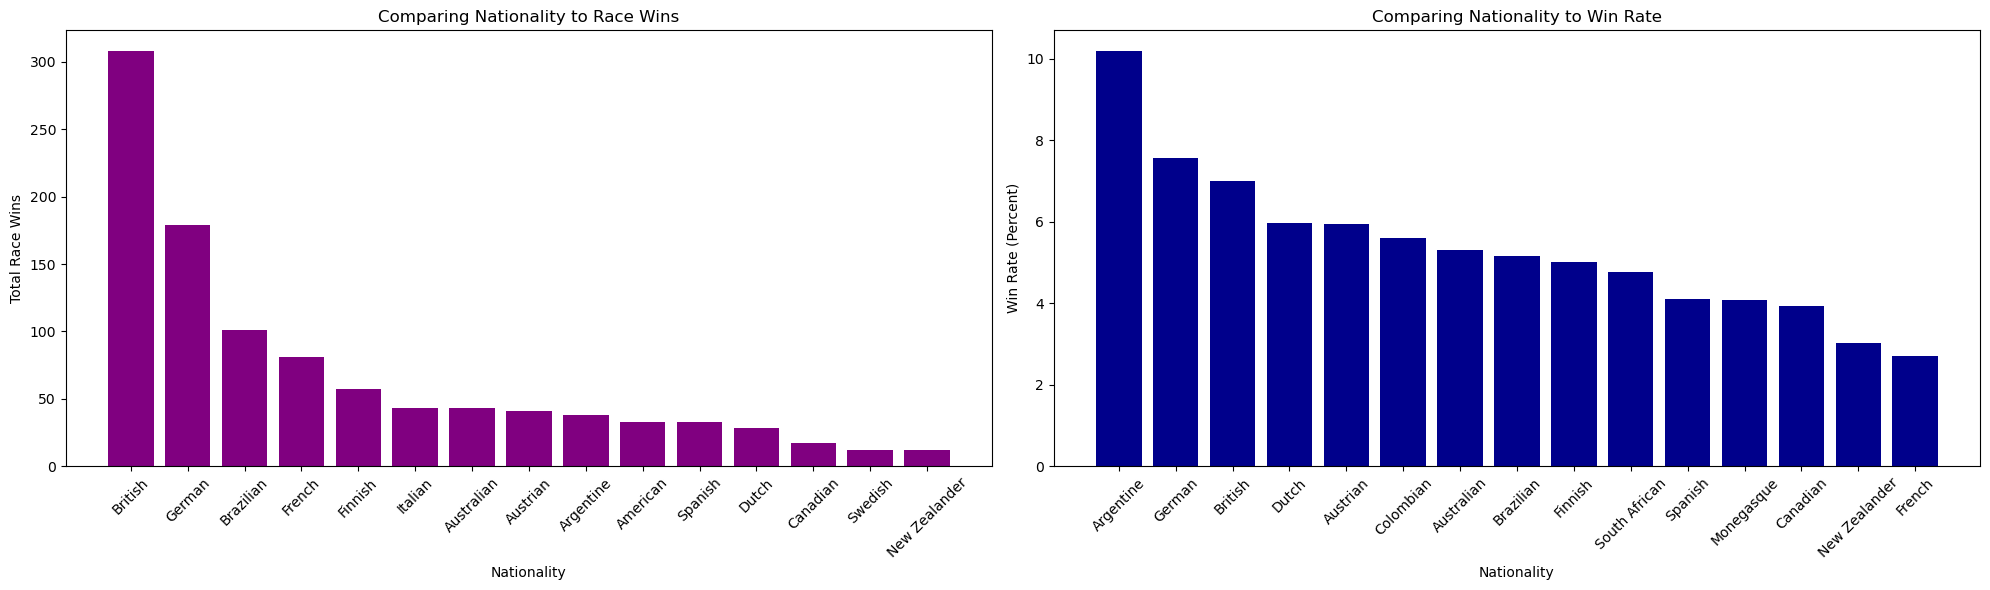

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
most_wins = metrics_q1.sort_values('total_wins', ascending=False).query('starts >= 100').head(15)
ax[0].bar('nationality', 'total_wins', data=most_wins, color='purple')
ax[0].set_xticks(range(len(most_wins)))
ax[0].set_xticklabels(most_wins['nationality'], rotation=45)
ax[0].set_xlabel("Nationality")
ax[0].set_ylabel("Total Race Wins")
ax[0].set_title("Comparing Nationality to Race Wins")
best_winrate = metrics_q1.sort_values('win_rate', ascending=False).query('starts >= 100').head(15)
ax[1].bar('nationality', 'win_rate', data=best_winrate, color='darkblue')
ax[1].set_xticks(range(len(best_winrate)))
ax[1].set_xticklabels(best_winrate['nationality'], rotation=45)
ax[1].set_xlabel("Nationality")
ax[1].set_ylabel("Win Rate (Percent)")
ax[1].set_title("Comparing Nationality to Win Rate")
plt.tight_layout()
plt.show()

Total wins alone can be misleading since countries with more drivers are bound to get more entries. The figure on the right instead compares nationalities by win rate — the percentage of race starts that resulted in a win. As seen, the ranking shifts considerably. Argentina jumps to first at over 10%. This is essentially entirely because of Juan Manuel Fangio's dominance in the 1950s. Germany moves to second largely by Michael Schumacher. Britain drops to third despite leading in raw wins, highlighting the fact that many in its large driver pool includes have never won.

Shifting to Question 2, the figure below tracks the mean age of all drivers competing in each season from 1950 to present. In 1950 the average driver was close to 40 years old. Early F1 was consistent of experienced racers from different types of racing. Age declined sharply through the 1950s and 1960s as the sport professionalized, stablizing around 28 since ~1995, suggesting the modern young driver pipeline consistently feeds young talent into the grid (Kimi Antonelli and 2015 Max Verstappen).

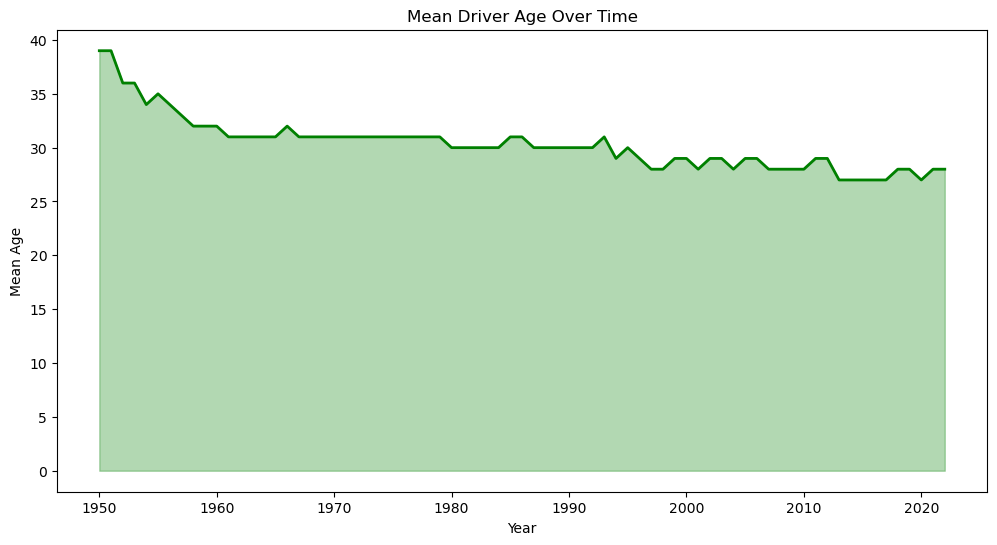

In [8]:
plt.figure(figsize=(12, 6))
plt.plot('year', 'avg_age', data=metrics_q2, color='green', linewidth=2)
plt.fill_between(metrics_q2['year'], metrics_q2['avg_age'], alpha=0.3, color='green')
plt.xlabel("Year")
plt.ylabel("Mean Age")
plt.title("Mean Driver Age Over Time")
plt.show()

The figure below tracks the number of distinct nationalities represented on the F1 grid each season. Diversity peaked in the mid-1970s at nearly 19 nationalities when the number of unique drivers was huge (~50-60). It dropped sharply through the 1980s and 1990s as the number of unique drivers shrunk and European teams favored European drivers. Since 2000 it has partially recovered to around 14-15, though it remains below its historical peak.

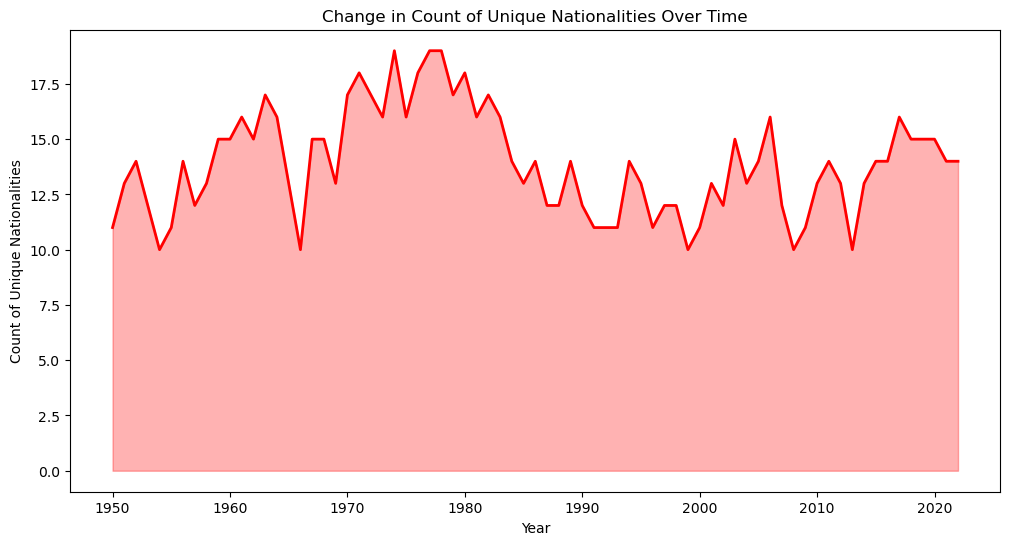

In [9]:
plt.figure(figsize=(12, 6))
plt.plot('year','unique_nationalities', data=metrics_q2, color = 'red', linewidth=2)
plt.fill_between(metrics_q2['year'], metrics_q2['unique_nationalities'], alpha=0.3, color='red')
plt.xlabel("Year")
plt.ylabel("Count of Unique Nationalities")
plt.title("Change in Count of Unique Nationalities Over Time")
plt.show()


Now Quetion 3. The figure below tracks the percentage of drivers who did not finish (DNF) each season from 1950 to present. In the early decades of the sport DNF rates hovered around 50-60%. This shows how unreliable and almost dangerous the cars were during that time. The rate peaked at just about 70% right around 1990 before beginning a sharp and continued decline through the 1990s and 2000s as advances in engineering grew, stricter FIA regulations were put in place, and better overall manufacturing all brought the rate down to around 15-20% in the current era. Similar to the drop in age over time, this figure goes to show how the sport of open-wheel racing has modernized.

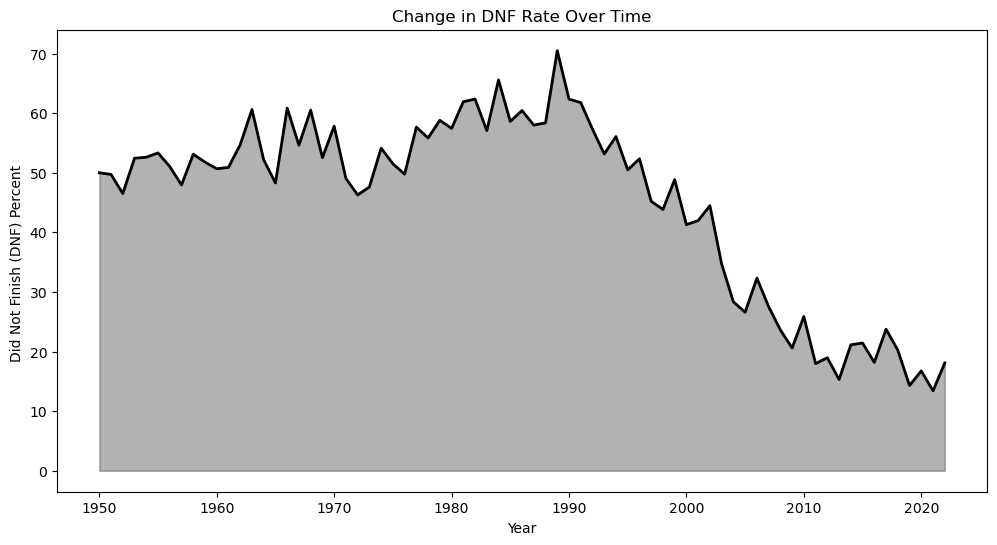

In [10]:
plt.figure(figsize=(12, 6))
plt.plot('year', 'dnf_rate', data=dnf_rate, color='black', linewidth=2)
plt.fill_between(dnf_rate['year'], dnf_rate['dnf_rate'], alpha=0.3, color='black')
plt.xlabel("Year")
plt.ylabel("Did Not Finish (DNF) Percent ")
plt.title("Change in DNF Rate Over Time")
plt.show()

The bar chart below displays the ten most common causes of retirement across all F1 races since 1950. Engine failures are the most common cause by a wide margin with just over 2,000 occurrences, about 2x second place. Accident and "Did not qualify" follow, with Collision, Gearbox, and Spun off all clustered closely together. It is important to clarify, "Did not qualify" and "Did not prequalify" are not mid-race retirements. They are reserved for when the driver does not make it even to the start of the race. This was **significantly** more common during the early years of F1 when technological gaps were larger and there were more competitors than gridspots, now being a very rare occurence.

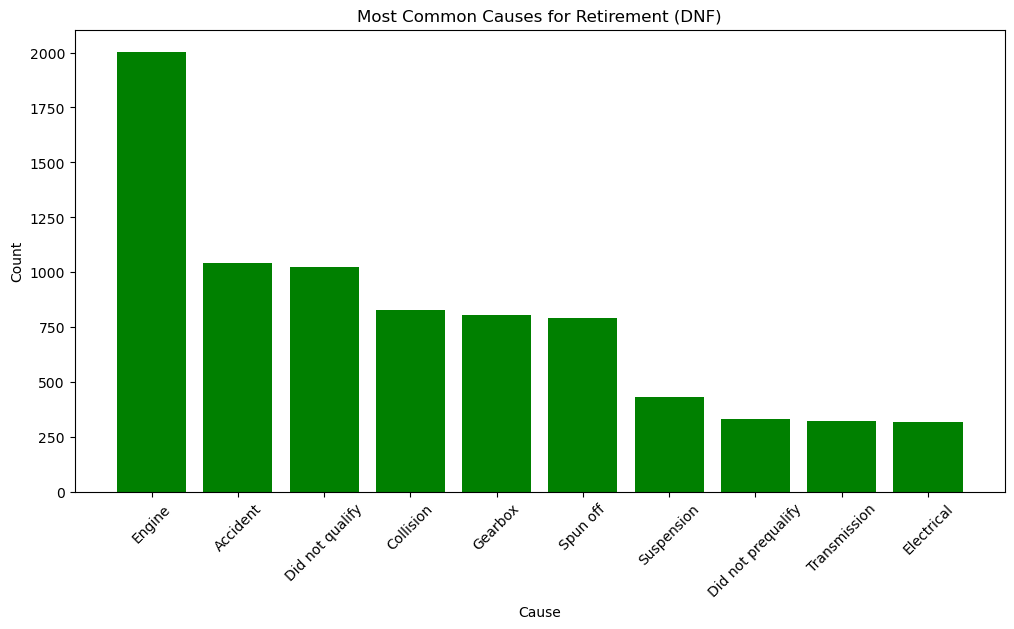

In [11]:
plt.figure(figsize=(12,6))
plt.bar('status', 'count', data=top_causes.head(10), color='green')
plt.xticks(rotation=45)
plt.xlabel("Cause")
plt.ylabel("Count")
plt.title("Most Common Causes for Retirement (DNF)")
plt.show()

## **Discussion**

Our findings show that success by nation in F1 follows two main patterns. Britain leads on every absolute measure (308 wins, 20 titles, 165 distinct drivers) through a strong supply of competitive drivers across decades. Germany and Argentina look very different. They have few distinct drivers but high win rates (7.57% and 10.19%), driven by generational talents like Schumacher and Fangio. France and Italy show the inverse, they have large driver pools that have low rates (2.71% and 1.26%). The leaderboard depends heavily on how "best" is defined, and restricting to nationalities with at least 100 starts was necessary to keep one time podiums from biasing the rankings.

We also found the typical F1 driver has also gotten younger and more "international" over time. Mean age fell from 39 in 1950 to 27 by 2013 and has held around 28 since then. This reflects the junior categories that now bring talent into F1 at the early 20s rather than admitting part time entrants in their 30s and 40s. National diversity peaked at 19 nationalities in 1974 and now sits at 14–15. This is more diverse than the 1950s but below the 1970s high. Part of the gap is likely just that modern grids only have around 20 drivers per season, compared to 60+ in the early years, so there are fewer slots for different nationalities to fill.

Our third finding surrounds reliability and race completion. DNF rates were very high during the early years of Formula One, sitting around 50% through the 1950s-1980s while peaking at just about 70% in 1988. Then, a sharp decline from the 1990s onward shows the major advances in car engineering and stricter FIA rule regulations. Today, the DNF rate sits around 15-20%. This means the large majority of drivers who begin a race will also go on to finish it. We also saw that engine failure of some kind has been **THE** most common cause of retirement across all of Formula One time followed by accidents and collisions. The change  from mechanical failures towards more racing kinds of incidents as the main cause of DNFs in the modern era go on to truly highlight the increase in reliability seen in modern Formula One cars compared to their early ancestors.